# 🛒 Customer Churn Prediction — RetailPulse RFM
**Goal:** Predict which customers are likely to churn based on their RFM (Recency, Frequency, Monetary) behaviour.

**Dataset:** `retailpulse_rfm.csv`  
**Model:** XGBoost Classifier  
**Interpretability:** SHAP values

---
> **Notebook structure**
> 1. Setup & Imports  
> 2. Data Loading & Sanity Check  
> 3. Exploratory Data Analysis (EDA)  
> 4. Target Engineering *(churn label creation)*  
> 5. Feature Selection & Leakage Audit  
> 6. Train/Test Split  
> 7. Model Training  
> 8. Evaluation  
> 9. SHAP Interpretability  
> 10. Production Notes

## 1. Setup & Imports

In [1]:
!pip install xgboost shap scikit-learn matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from xgboost import XGBClassifier
import shap

# ── Consistent plot style ──────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("All imports successful ✓")

All imports successful ✓


## 2. Data Loading & Sanity Check

Before anything else, we inspect the data for shape, types, and missing values.  
**Never skip this step** — silent data issues (wrong dtypes, hidden NaNs) corrupt everything downstream.

In [3]:
df = pd.read_csv("retailpulse_rfm.csv")

print("Shape:", df.shape)
print()
print("Column types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
df.head()

Shape: (5878, 10)

Column types:
CustomerID      int64
Recency         int64
Frequency       int64
Monetary      float64
R_Score         int64
F_Score         int64
M_Score         int64
RFM_Score       int64
RFM_Total       int64
Segment           str
dtype: object

Missing values per column:
CustomerID    0
Recency       0
Frequency     0
Monetary      0
R_Score       0
F_Score       0
M_Score       0
RFM_Score     0
RFM_Total     0
Segment       0
dtype: int64



,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment
0,12346,326,12,77556.46,2,5,5,255,12,Loyal Customers
1,12347,2,8,4921.53,5,4,5,545,14,Champions
2,12348,75,5,2019.40,3,4,4,344,11,Loyal Customers
3,12349,19,4,4428.69,5,3,5,535,13,Champions
4,12350,310,1,334.40,2,1,2,212,5,At Risk


In [4]:
# Statistical summary — look for extreme outliers in Monetary/Frequency
df.describe().round(2)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
count,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00,5878.00
mean,15315.31,201.33,6.29,2955.90,3.01,3.00,3.00,333.51,9.01
std,1715.57,209.34,13.01,14440.85,1.42,1.41,1.41,150.38,3.64
min,12346.00,1.00,1.00,2.95,1.00,1.00,1.00,111.00,3.00
25%,13833.25,26.00,1.00,342.28,2.00,2.00,2.00,214.00,6.00
50%,15314.50,96.00,3.00,867.74,3.00,3.00,3.00,334.00,9.00
75%,16797.75,380.00,7.00,2248.30,4.00,4.00,4.00,454.00,12.00
max,18287.00,739.00,398.00,580987.04,5.00,5.00,5.00,555.00,15.00


## 3. Exploratory Data Analysis (EDA)

EDA is not optional. It tells you:
- How skewed your features are (affects tree depth tuning)
- Whether outliers exist (e.g. a ₹10 lakh single transaction)
- How correlated the features are with each other

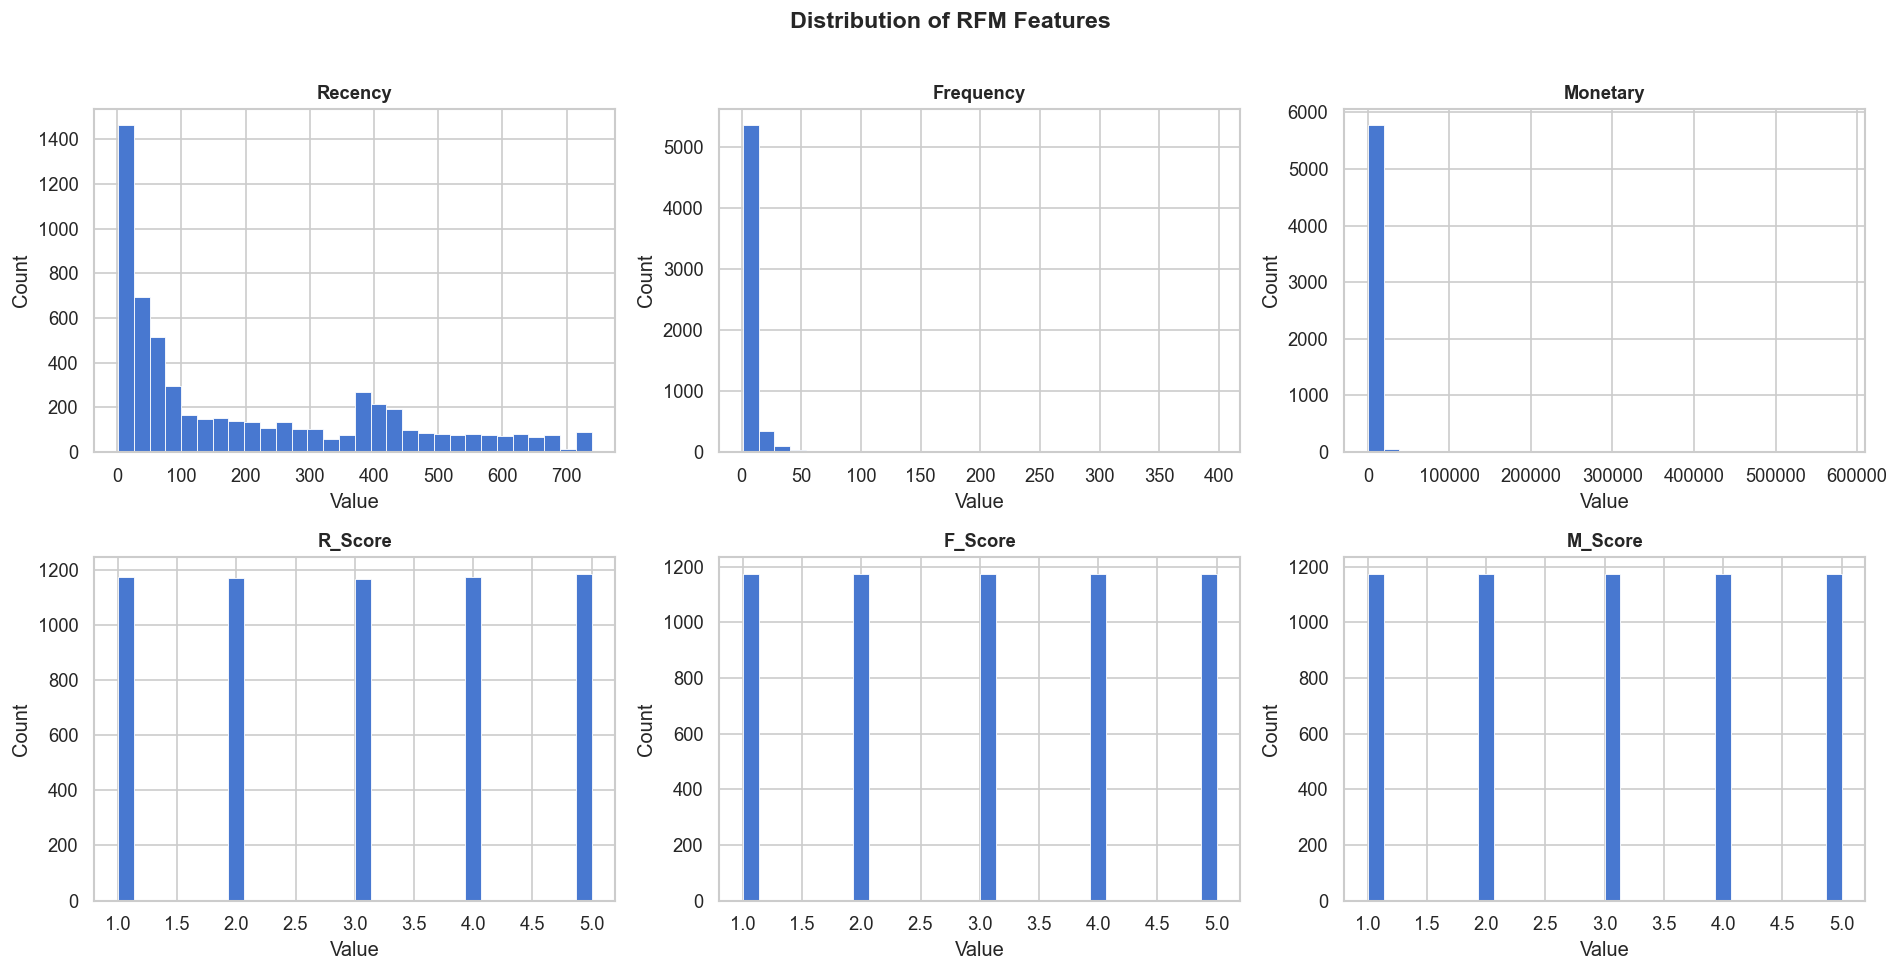

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

rfm_cols = ["Recency", "Frequency", "Monetary", "R_Score", "F_Score", "M_Score"]

for i, col in enumerate(rfm_cols):
    axes[i].hist(df[col], bins=30, edgecolor="white", linewidth=0.5)
    axes[i].set_title(col, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Distribution of RFM Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

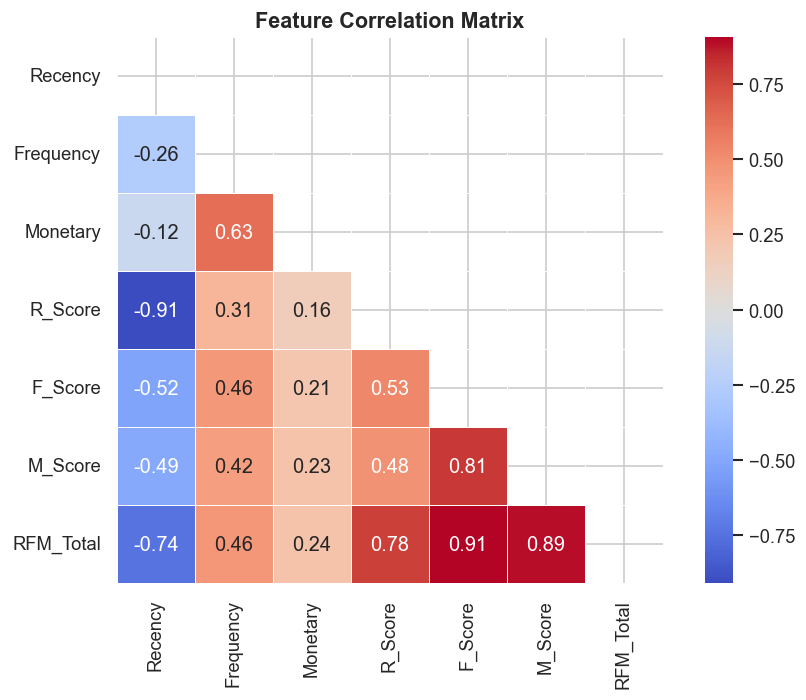


⚠️  Note: R_Score is derived from Recency, F_Score from Frequency, M_Score from Monetary.
   High correlation between raw and scored columns is expected.
   RFM_Total = R_Score + F_Score + M_Score — it encodes ALL three.


In [6]:
# Correlation heatmap — check for multicollinearity
plt.figure(figsize=(8, 6))
corr = df[rfm_cols + ["RFM_Total"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print()
print("⚠️  Note: R_Score is derived from Recency, F_Score from Frequency, M_Score from Monetary.")
print("   High correlation between raw and scored columns is expected.")
print("   RFM_Total = R_Score + F_Score + M_Score — it encodes ALL three.")

## 4. Target Engineering — Creating the Churn Label

We define a customer as **churned** if they have not purchased in the last 180 days.

```
Churn = 1  if Recency > 180 days
Churn = 0  if Recency ≤ 180 days
```

This is a **business decision**, not a technical one. In a real project, align this threshold with your product team.

> **Common mistake:** Using 90, 180, or 365 days without checking the data's actual recency distribution.  
> Run the cell below to verify the threshold makes sense for your data.

In [7]:
# Check recency distribution BEFORE committing to the threshold
print("Recency percentiles:")
print(df["Recency"].quantile([0.25, 0.50, 0.75, 0.90, 0.95]).round(1))
print(f"\nMax recency: {df['Recency'].max()} days")
print(f"Proposed churn threshold: 180 days")
print(f"% customers flagged as churned at 180d: {(df['Recency'] > 180).mean()*100:.1f}%")

Recency percentiles:
0.25     26.0
0.50     96.0
0.75    380.0
0.90    535.0
0.95    625.0
Name: Recency, dtype: float64

Max recency: 739 days
Proposed churn threshold: 180 days
% customers flagged as churned at 180d: 40.8%


Class Distribution:
  Non-churned (0): 3,478  (59.2%)
  Churned     (1): 2,400  (40.8%)


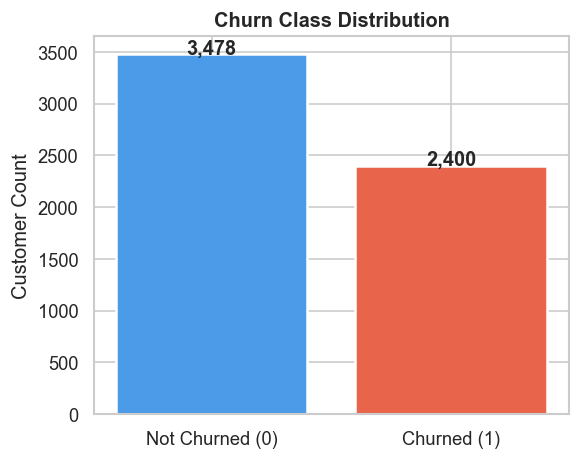


✓ Classes are reasonably balanced.


In [8]:
# ── Create the churn label ─────────────────────────────────────────────────
CHURN_THRESHOLD = 180  # days — change here if needed

df["Churn"] = (df["Recency"] > CHURN_THRESHOLD).astype(int)

# ── Class distribution ─────────────────────────────────────────────────────
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Class Distribution:")
print(f"  Non-churned (0): {churn_counts[0]:,}  ({churn_pct[0]:.1f}%)")
print(f"  Churned     (1): {churn_counts[1]:,}  ({churn_pct[1]:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Not Churned (0)", "Churned (1)"], churn_counts,
       color=["#4C9BE8", "#E8654C"], edgecolor="white", linewidth=1.5)
ax.set_title("Churn Class Distribution", fontsize=12, fontweight="bold")
ax.set_ylabel("Customer Count")
for i, v in enumerate(churn_counts):
    ax.text(i, v + 5, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print()
if churn_pct.min() < 20:
    print("⚠️  Class imbalance detected! The minority class is under 20%.")
    print("   We'll set scale_pos_weight in XGBoost to compensate.")
else:
    print("✓ Classes are reasonably balanced.")

## 5. Feature Selection & Data Leakage Audit

### 🚨 Critical: Data Leakage from `Recency`

This is the most important cell in the notebook.

**Leakage** means that a feature in your training data directly encodes the answer you're trying to predict.  
When leakage exists, your model achieves artificially high accuracy but fails completely on real new data.

**The bug in the original notebook:**  
`Churn` was defined as `Recency > 180`, then `Recency` was included as a feature.  
The model learned: *"if Recency > 180 → predict churn."*  
It didn't learn anything about customer behaviour — it just memorised the rule.

**Also affected:**
- `R_Score` — scored version of Recency (directly encodes recency rank → leaks target)
- `RFM_Total` = R_Score + F_Score + M_Score — includes R_Score, so it partially leaks

**Fix:** Remove `Recency`, `R_Score`, and `RFM_Total` from the feature set.  
The remaining features — `Frequency`, `Monetary`, `F_Score`, `M_Score` — are genuinely predictive  
without leaking the churn definition.

In [9]:
# ── Feature set AFTER removing leaky columns ──────────────────────────────
# Removed:
#   Recency   → directly defines Churn (Recency > 180)
#   R_Score   → derived from Recency — leaks the same information in a scored form
#   RFM_Total → R_Score + F_Score + M_Score — partially leaks via R_Score

features = [
    "Frequency",   # How often the customer bought — genuinely predictive
    "Monetary",    # How much they spent — genuinely predictive
    "F_Score",     # Frequency score (quintile rank) — clean
    "M_Score",     # Monetary score (quintile rank) — clean
]

X = df[features]
y = df["Churn"]

print("✓ Features selected (no leakage):", features)
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print()
print("Correlation of features with target (Churn):")
print(X.assign(Churn=y).corr()["Churn"].drop("Churn").round(3))

✓ Features selected (no leakage): ['Frequency', 'Monetary', 'F_Score', 'M_Score']

X shape: (5878, 4)
y shape: (5878,)

Correlation of features with target (Churn):
Frequency   -0.236
Monetary    -0.114
F_Score     -0.468
M_Score     -0.445
Name: Churn, dtype: float64


## 6. Train / Test Split

**Why `stratify=y`?**  
Without it, a random split could put 90% of churned customers in the training set by chance.  
Stratification guarantees the churn ratio is preserved in both splits — essential for imbalanced data.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ← preserves churn ratio in both splits
)

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print()
print("Churn rate in training set:", y_train.mean().round(3))
print("Churn rate in test set    :", y_test.mean().round(3))
print("✓ Rates are consistent — stratify worked correctly")

Training set : 4,702 rows
Test set     : 1,176 rows

Churn rate in training set: 0.408
Churn rate in test set    : 0.408
✓ Rates are consistent — stratify worked correctly


## 7. Model Training

### Why XGBoost?
- Handles mixed-type features (raw scores + ordinal scores) well
- Built-in regularisation (prevents overfitting without needing `StandardScaler`)
- `scale_pos_weight` handles class imbalance natively without SMOTE or resampling

### `scale_pos_weight`
For imbalanced datasets, this parameter tells XGBoost to penalise missing churned customers  
more heavily than missing non-churned ones.  
The formula: `scale_pos_weight = count(negative class) / count(positive class)`

In [11]:
# ── Compute class weight for imbalance handling ────────────────────────────
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"Negative (non-churn): {neg:,}")
print(f"Positive (churn):     {pos:,}")
print(f"scale_pos_weight:     {scale_pos_weight:.2f}")

Negative (non-churn): 2,782
Positive (churn):     1,920
scale_pos_weight:     1.45


In [12]:
# ── Train XGBoost ──────────────────────────────────────────────────────────
model = XGBClassifier(
    n_estimators=300,          # more trees → better; early stopping will cap it
    max_depth=4,               # shallow trees avoid overfitting on RFM data
    learning_rate=0.05,        # lower lr + more trees generally outperforms 0.1
    subsample=0.8,             # row subsampling — adds regularisation
    colsample_bytree=0.8,      # column subsampling — adds regularisation
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    eval_metric="auc",
    early_stopping_rounds=20,  # stop if AUC doesn't improve for 20 rounds
    random_state=42,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],   # monitor test AUC during training
    verbose=False
)

print(f"✓ Training complete. Best iteration: {model.best_iteration}")

✓ Training complete. Best iteration: 37


## 8. Cross-Validation — Is the Model Stable?

A single train/test split can be lucky or unlucky.  
**Stratified 5-fold cross-validation** trains and evaluates on 5 different splits,  
giving you a mean AUC ± standard deviation — a much more reliable estimate.

> **Rule of thumb:** If std > 0.03, your model is unstable. Consider more data or simpler features.

In [13]:
# We use a fresh unfitted model for CV to avoid data leakage from early stopping
cv_model = XGBClassifier(
    n_estimators=model.best_iteration,  # use best iteration found above
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(cv_model, X, y, cv=skf, scoring="roc_auc", n_jobs=-1)

print("5-Fold Stratified Cross-Validation AUC:")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s:.4f}")
print(f"\n  Mean AUC : {cv_scores.mean():.4f}")
print(f"  Std  AUC : {cv_scores.std():.4f}")

if cv_scores.std() < 0.03:
    print("\n✓ Model is stable across folds.")
else:
    print("\n⚠️  High variance across folds — consider more data or feature review.")

5-Fold Stratified Cross-Validation AUC:
  Fold 1: 0.7637
  Fold 2: 0.7825
  Fold 3: 0.8033
  Fold 4: 0.8012
  Fold 5: 0.7781

  Mean AUC : 0.7858
  Std  AUC : 0.0149

✓ Model is stable across folds.


## 9. Model Evaluation

We evaluate across four dimensions:
1. **Classification Report** — Precision, Recall, F1 per class
2. **Confusion Matrix** — Visualise which mistakes the model makes
3. **ROC Curve** — Overall discrimination ability
4. **Precision-Recall Curve** — Most informative for imbalanced datasets

> For churn, **Recall (Sensitivity)** is often more important than Precision:  
> Missing a churner who *does* leave is more expensive than falsely flagging one who stays.

In [14]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ── AUC on train vs test (overfitting check) ───────────────────────────────
train_auc = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test, y_prob)
ap_score  = average_precision_score(y_test, y_prob)

print(f"Train AUC-ROC : {train_auc:.4f}")
print(f"Test  AUC-ROC : {test_auc:.4f}  ← primary metric")
print(f"Avg Precision : {ap_score:.4f}  (area under PR curve)")
gap = train_auc - test_auc
print(f"\nTrain-Test Gap: {gap:.4f}", end="  ")
if gap < 0.03:
    print("✓ No significant overfitting")
elif gap < 0.07:
    print("⚠️  Mild overfitting — consider reducing n_estimators or max_depth")
else:
    print("❌ Overfitting detected — model needs regularisation")

print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Churned", "Churned"]))

Train AUC-ROC : 0.7992
Test  AUC-ROC : 0.7745  ← primary metric
Avg Precision : 0.6695  (area under PR curve)

Train-Test Gap: 0.0246  ✓ No significant overfitting

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.79      0.68      0.73       696
     Churned       0.62      0.74      0.67       480

    accuracy                           0.71      1176
   macro avg       0.70      0.71      0.70      1176
weighted avg       0.72      0.71      0.71      1176



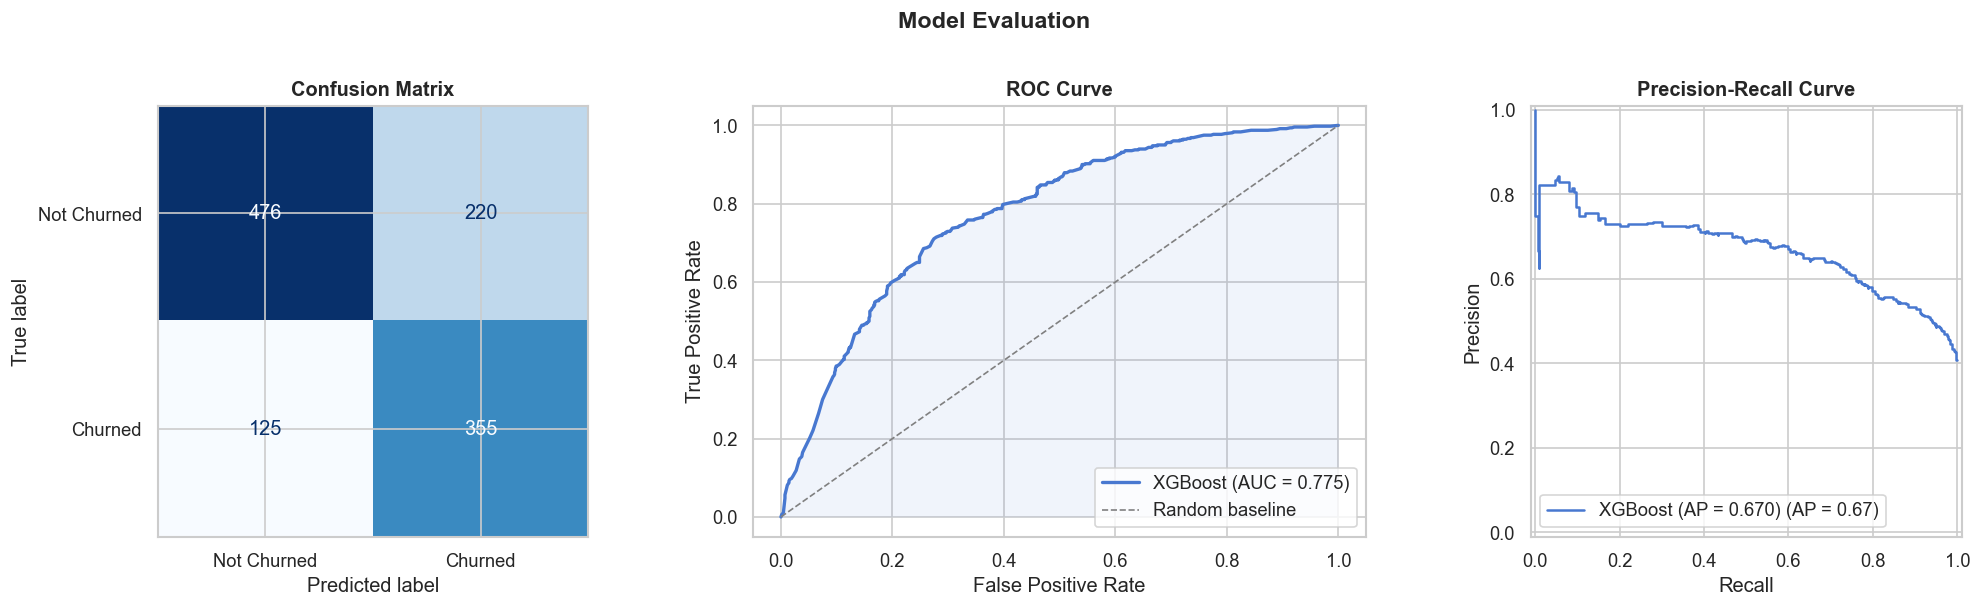

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. Confusion Matrix ─────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Not Churned", "Churned"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix", fontsize=12, fontweight="bold")

# ── 2. ROC Curve ────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, lw=2, label=f"XGBoost (AUC = {test_auc:.3f})")
axes[1].plot([0,1],[0,1],"--", color="grey", lw=1, label="Random baseline")
axes[1].fill_between(fpr, tpr, alpha=0.08)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right")

# ── 3. Precision-Recall Curve ───────────────────────────────────────────────
PrecisionRecallDisplay.from_predictions(
    y_test, y_prob, ax=axes[2],
    name=f"XGBoost (AP = {ap_score:.3f})"
)
axes[2].set_title("Precision-Recall Curve", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")

plt.suptitle("Model Evaluation", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 10. SHAP — Understanding Model Decisions

**SHAP (SHapley Additive exPlanations)** tells you:
- Which features pushed a prediction toward "churn" or "not churn"
- How much each feature contributed, for every individual customer

This is what separates a **production-ready model** from a black box.  
In a real project, you'd use this to build targeted retention campaigns:  
*"This customer is high-risk because their purchase frequency dropped — send a discount."*

Beeswarm Plot — each dot is one customer.
Red = high feature value, Blue = low feature value.
X-axis = impact on churn prediction (positive → pushed toward churn)



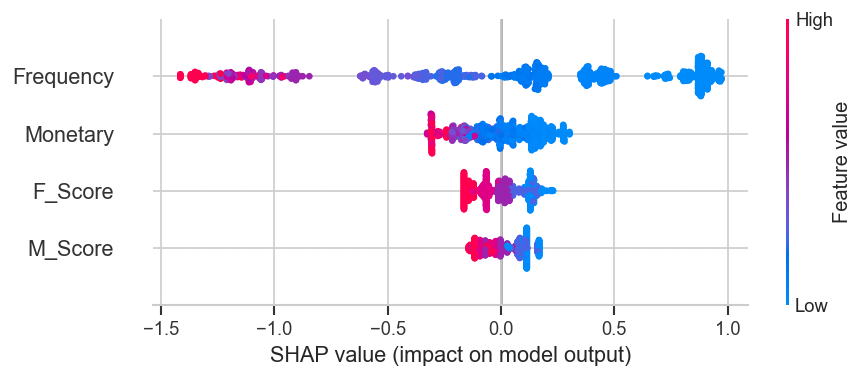

In [16]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# ── Beeswarm: overall feature impact ───────────────────────────────────────
print("Beeswarm Plot — each dot is one customer.")
print("Red = high feature value, Blue = low feature value.")
print("X-axis = impact on churn prediction (positive → pushed toward churn)\n")
shap.plots.beeswarm(shap_values, max_display=len(features), show=True)

Mean |SHAP| — which features matter most on average:


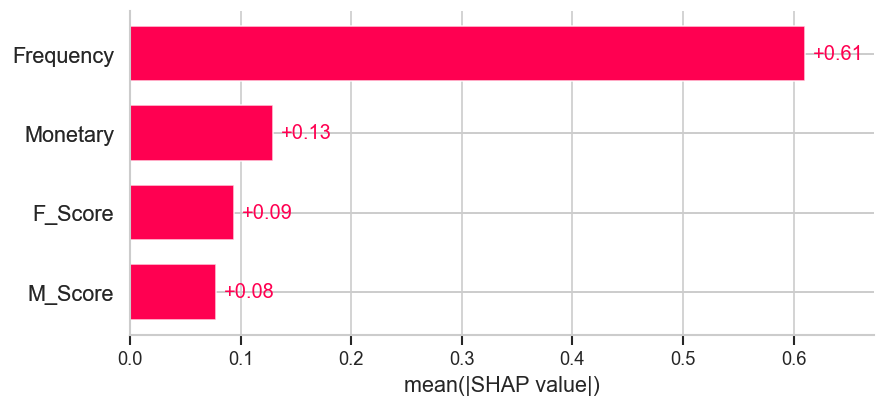

In [17]:
# ── Bar plot: mean absolute SHAP (feature importance) ─────────────────────
print("Mean |SHAP| — which features matter most on average:")
shap.plots.bar(shap_values, max_display=len(features), show=True)

Explaining prediction for highest-risk customer (index 2):
Predicted churn probability: 79.88%
Actual churn label: 0



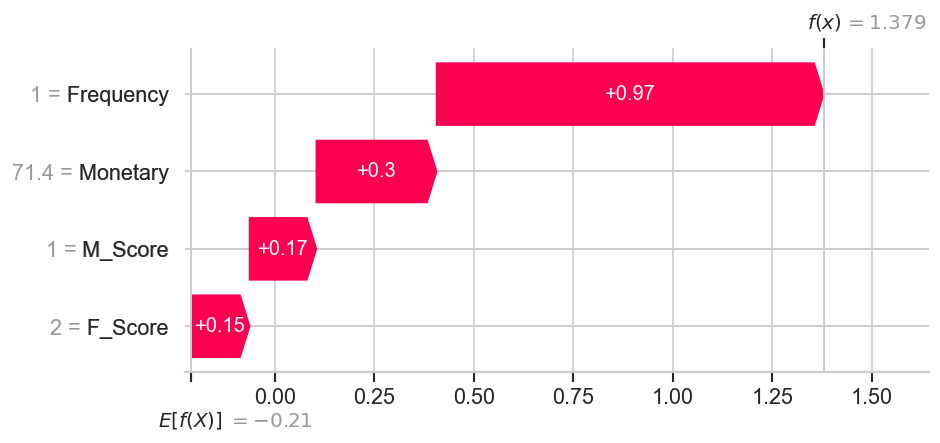

In [18]:
# ── Waterfall: explain one customer's prediction ──────────────────────────
# Find the highest-risk customer in the test set
highest_risk_idx = np.argmax(y_prob)

print(f"Explaining prediction for highest-risk customer (index {highest_risk_idx}):")
print(f"Predicted churn probability: {y_prob[highest_risk_idx]:.2%}")
print(f"Actual churn label: {y_test.iloc[highest_risk_idx]}\n")
shap.plots.waterfall(shap_values[highest_risk_idx], show=True)